In [1]:
import numpy as np
import _pickle as pickle
import pandas as pd
import os

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy.stats import binned_statistic, lognorm

In [2]:
import sys
sys.path.append('/home/submit/aqc/frb_project')
from illustris_frb import simulation, exp_simulation
from illustris_frb.regions import regions
from illustris_frb.xcorr import cross_power_estimator

sim = simulation()

g_zrange = (0.2, 0.3)
frb_zrange = (0.3, 0.4)
frb_xrange = sim.comoving_distance(frb_zrange)
frb_mean_x = np.mean(frb_xrange)
frb_mean_z = sim.z_from_dist(frb_mean_x)
nbins = 10
print(frb_mean_z)

0.3492729716291206


In [3]:
# load in results

res_path = '/ceph/submit/data/group/submit-illustris/april/data/C_ells/trial_experiments.pkl'
with open(res_path, 'rb') as f:
    res = pickle.load(f)
print(list(res.keys()))

ells = res['l']

midslice_ClDgs = res['midslice']['ClDg']
midslice_DeltaCs = res['midslice']['DeltaCs']

n_frbs = 2000
fid_ClDgs = res['n_frbs_sfrweight'][n_frbs]

midslice_DMs = np.stack(res['midslice']['DMs'], axis=0)
fid_DMs, fid_mults = np.stack(res['trial_DM_fields']['DM_fid'], axis=0), np.stack(res['trial_DM_fields']['mult_fid'], axis=0)
fid_DMs_ = fid_DMs[fid_mults > 0].flatten()

['regions', 'N_gs', 'host_properties', 'midslice', 'l', 'trial_DM_fields', 'fullz_FRB_properties', 'n_frbs_sfrweight', 'n_frbs_massweight', 'n_frbs_randpixels', 'n_frbs_injhostDM', 'DM_sfunc_injhostDM', 'DM_cutoffs', 'DM_cutoffs_injhostDM', 'm_g_cutoffs', 'proj_sfrweight_ClDgs', 'overlap_frb_zranges', 'DM_sfunc', 'scatter_ClDgs', 'host_m_g_cutoffs']


In [4]:
# load in combined results

combined_res_path = '/ceph/submit/data/group/submit-illustris/april/data/C_ells/combined_experiment.pkl'
with open(combined_res_path, 'rb') as f:
    combined_res = pickle.load(f)
print(list(combined_res.keys()))

scatterPs_slice, scatterPs_full = 1 - np.concatenate(combined_res['scatterPs_slice']), 1 - np.concatenate(combined_res['scatterPs_full'])

['regions', 'slice_exp', 'full_exp', 'scatterPs_full', 'scatterPs_slice', 'midslice', 'full', 'l']


### plotting helper functions

In [5]:
figpath = '/home/submit/aqc/frb_project/figures_final'

colorcycle = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
              '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

colorblind = sns.color_palette('colorblind')
mako = sns.color_palette("mako_r", 4)
flare = sns.color_palette("flare", 4)
magma = sns.color_palette("magma_r")
fid_c = 'k'

plt.style.use({
    'font.family':        'serif',
    'font.serif':         ['DejaVu Sans'],
    'mathtext.fontset':   'stixsans',
    'figure.figsize':     (6,4),
    'legend.fontsize':    11,
    'legend.framealpha':  0.5,
    'lines.markersize':   1.5,
    'text.usetex':        False,
    'figure.dpi':         120,
    'savefig.dpi':        250,
    'savefig.bbox':       'tight',
    'savefig.pad_inches': 0.1,
    'axes.prop_cycle':    plt.cycler('color', colorcycle)
})

In [6]:
default_xlim = (100, 4000)
default_lin_ylim = (-0.0005, 0.004)
default_lin_yticks = (0, 0.001, 0.002, 0.003, 0.004)
default_log_ylim = (1e-6, 1e-2)

In [7]:
# cross-correlation power spectrum plotting functions

def plot_xcorr(ells, C_ls, ax=None, label=None, color='k', lw=1, 
               xlim=None, ylim=None, yticks=None, DeltaCs=None, xlabel=r'$\ell$',
               ylabel=r'$C_{\ell}^{Dg}$', alpha=1, xscale='log', yscale='log', **kwargs):

    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(ells, C_ls, lw=lw, color=color, alpha=alpha, **kwargs)
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel, labelpad=2)

    if xlim is None:
        # ax.set_xlim((ells[0], ells[-1]))
        ax.set_xlim(default_xlim)
    else:
        ax.set_xlim(xlim)
    
    if ylim is None:
        if yscale == 'log':
            ax.set_ylim(default_log_ylim)
        elif yscale == 'linear':
            ax.set_ylim(default_lin_ylim)
            ax.set_yticks(default_lin_yticks)
    else:
        ax.set_ylim(ylim)
        ax.set_yticks(yticks)

    if DeltaCs is not None:
        if len(DeltaCs)==2:
            ax.fill_between(ells, DeltaCs[0], DeltaCs[1], label=label, color=color, alpha=alpha*0.3)
        else:
            ax.fill_between(ells, C_ls-DeltaCs, C_ls+DeltaCs, label=label, color=color, alpha=alpha*0.3)

def plot_xcorr_trials(ells, C_l_list, ax=None, plotinterval=True, **kwargs):
    C_l_arr = np.vstack(C_l_list)
    if ax is None:
        fig, ax = plt.subplots()
    if plotinterval:
        interval = (np.percentile(C_l_arr, 16, axis=0), np.percentile(C_l_arr, 84, axis=0))
        plot_xcorr(ells, np.median(C_l_arr, axis=0), ax=ax, DeltaCs=interval, **kwargs)
    else:
        plot_xcorr(ells, np.mean(C_l_arr, axis=0), ax=ax, DeltaCs=np.std(C_l_arr, axis=0), **kwargs)

def plot_ref_ClDg(ax, ref_ClDg=midslice_ClDgs, lw1=0.7, lw2=0.5, ells=ells, color=None, label='default'):
    if label == 'default':
        if ref_ClDg is midslice_ClDgs:
            label = f'Uniform FRBs, $z = {frb_mean_z:.2f}$'
        elif ref_ClDg is fid_ClDgs:
            label = r'SFR, $0.3 < z_\text{host} \leq 0.4$'
    if color is None:
        if ref_ClDg is fid_ClDgs:
            color = fid_c
        else:
            color='k'
    if ref_ClDg is midslice_ClDgs:
        ax.plot(ells, np.median(ref_ClDg, axis=0), color=color, lw=lw1)
        ax.fill_between(ells, np.percentile(ref_ClDg, 16, axis=0), np.percentile(ref_ClDg, 84, axis=0), color=color, alpha=0.3, label=label)
    else:
        if lw1 > 0:
            ax.plot(ells, np.median(ref_ClDg, axis=0), color=color, lw=lw1, ls='--', label=label)
            label2=None
        else:
            label2=label
        if lw2 > 0:
            ax.plot(ells, np.percentile(ref_ClDg, 16, axis=0), color=color, lw=lw2, ls='--', label=label2)
            ax.plot(ells, np.percentile(ref_ClDg, 84, axis=0), color=color, lw=lw2, ls='--')

def subplot_from_list(results_list, ells=ells, ref_ClDg=None, ref_label='default', ref_lws=(1, 0.8), labels=None, 
                      ax=None, colors=colorcycle, legend=True, alpha=0.9, **kwargs):
    if ax is None:
        fig, ax = plt.subplots()
    ax.axhline(0, color='gray', ls='dotted', lw=0.8)
    if ref_ClDg is not None:
        plot_ref_ClDg(ax, ref_ClDg, lw1=ref_lws[0], lw2=ref_lws[1], label=ref_label)
    for i, result in enumerate(results_list):
        plot_xcorr_trials(ells, result, ax=ax, label=labels[i], color=colors[i], alpha=alpha, **kwargs)
    if legend:
        ax.legend()

# plot a dictionary of ClDg arrays
def subplot_from_dict(results_dict, whichkeys=None, ells=ells, ref_ClDg=None, ref_label='default', ref_lws=(1,0.8),
                     labels=None, ax=None, colors=colorcycle, legend=True, alpha=0.9, **kwargs):
    if whichkeys is None:
        whichkeys = list(results_dict.keys()) # which keys to plot
    else:
        whichkeys = [key for key in whichkeys if key in results_dict.keys()]
    if callable(labels):
        labels_ = [labels(key) for key in whichkeys]
    elif labels is None: # if no labels are given, default to dict keys
        labels_ = whichkeys
    else:
        labels_ = labels
    results_list = [results_dict[key] for key in whichkeys]
    subplot_from_list(results_list, ells, ref_ClDg, ref_label, ref_lws, labels_, ax, colors, legend, alpha, **kwargs)

# plot a list of dictionaries of ClDg arrays, one dictionary per subplot
def generate_plots(results_dict_list, titles=None, figsize=None, whichkeys=None, ref_ClDg=None,
                   labels=None, colors=colorcycle, ylim=None, **kwargs):
    n = len(results_dict_list)
    if figsize is None:
        if n==2:
            figsize = (9,4)
        if n==3:
            figsize = (13,4)
    fig, axes = plt.subplots(1, n, figsize=figsize, sharex=True, sharey=True)
    for i, results_dict in enumerate(results_dict_list):
        subplot_from_dict(results_dict, whichkeys=whichkeys, ref_ClDg=ref_ClDg, 
                         labels=labels, ax=axes[i], colors=colors, **kwargs)
        if titles is not None:
            axes[i].set_title(titles[i])
    if ylim is not None:
        axes[0].set_ylim(ylim)
    for ax in axes[1:]:
        ax.set_ylabel('')
        
    plt.tight_layout()
    return fig, axes

**Unless otherwise specified, all plots use the following fiducial model:**
- 2000 FRBs
- $0.3 < z_\text{host} \leq 0.4$
- FRBs placed in galaxies proportional to the SFR
- Cross-correlated with foreground galaxies with $0.2 < z_g \leq 0.3$

## cross-correlation is robust to host DM

We test the effect of increased DM variance from the host contribution by injecting a random host DM. A host DM is drawn from a log-normal distribution 
$$ P(\text{DM}) = \frac{1}{\sigma\,\text{DM} \sqrt{2\pi}} \exp \left[-\frac{(\ln \text{DM} - \mu)^2}{2\sigma^2} \right] $$
with $\mu = 1.93 / \log_{10} e$ and $\sigma = 0.41 / \log_{10} e$, values that are taken roughly from Table 1 of [the CHIME populations paper](https://arxiv.org/pdf/2207.14316).

In [90]:
# host DM log normal, from https://arxiv.org/pdf/2207.14316
mu, sigma = 1.93 / np.log10(np.e), 0.41 / np.log10(np.e)

host_DMs_ = np.random.lognormal(mu, sigma, len(fid_DMs_))

def lognormal(x, mu, sigma):
    return 1 / (x * sigma * np.sqrt(2 * np.pi)) * np.exp(-((np.log(x) - mu)**2) / (2 * sigma**2))

DMs_ = np.logspace(1, 4, 10000)
PDMs_ = lognormal(DMs_, mu, sigma) 

bins = np.logspace(0, 4, 100)
H_fid, _ = np.histogram(fid_DMs_, bins=bins, density=True)
H_fid_host, _ = np.histogram(fid_DMs_ + host_DMs_, bins=bins, density=True)

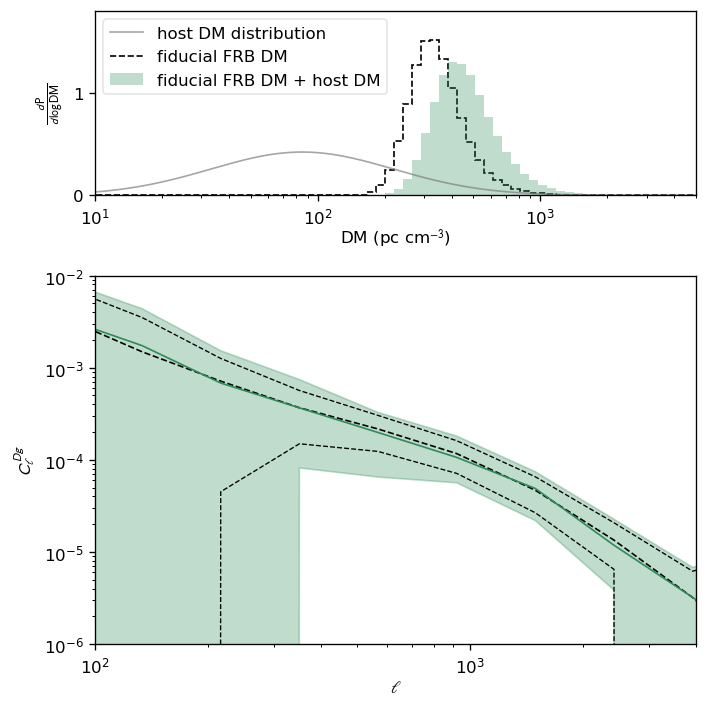

In [103]:
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 2])
fig = plt.figure(figsize=(6,6))

ax_hist = fig.add_subplot(gs[0])
ax = fig.add_subplot(gs[1])

c = 'seagreen'

# DM host histogram
DM_mids_ = (bins[:-1] + bins[1:]) / 2
_ = ax_hist.plot(DMs_, PDMs_ * DMs_, color='gray', label='host DM distribution', lw=1, alpha=0.7)
_ = ax_hist.stairs(H_fid * DM_mids_, bins, color=fid_c, label='fiducial FRB DM', ls='--')
_ = ax_hist.stairs(H_fid_host * DM_mids_, bins, color=c, label='fiducial FRB DM + host DM',fill=True, alpha=0.3)

ax_hist.set_xlabel('DM (pc cm$^{-3}$)', labelpad=0)
ax_hist.set_ylabel(r'$\frac{d\,\mathrm{P}}{d\,\log\mathrm{DM}}$')
ax_hist.set_xscale('log')
ax_hist.set_xlim((10, 5e3))
# ax_hist.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax_hist.set_yticks([0, 1])
ax_hist.set_ylim(0, 1.8)
ax_hist.legend(fontsize=10)

# cross-correlation
plot_ref_ClDg(ax, fid_ClDgs, 1, 0.8, label='fiducial')
plot_xcorr_trials(ells, res['n_frbs_injhostDM'][n_frbs], ax=ax, color=c, label='fiducial + host DM')
ax.axhline(0, color='gray', ls='dotted', lw=0.8)
# ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(figpath, 'hostDM_onelegend.pdf'))

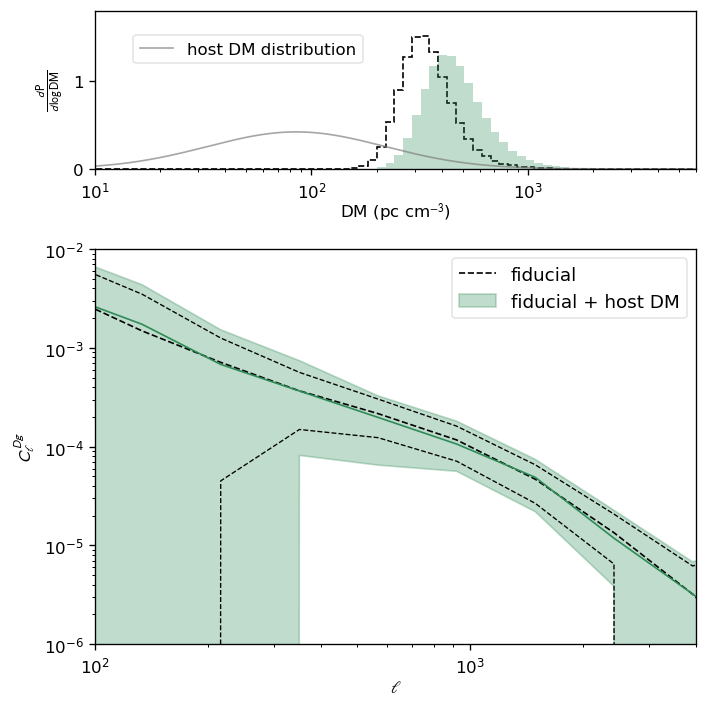

In [115]:
# I think this looks better with the legend on the bottom plot, but that's just my opinion 

gs = gridspec.GridSpec(2, 1, height_ratios=[1, 2.5])
fig = plt.figure(figsize=(6,6))

ax_hist = fig.add_subplot(gs[0])
ax = fig.add_subplot(gs[1])

c = 'seagreen'

# DM host histogram
DM_mids_ = (bins[:-1] + bins[1:]) / 2
_ = ax_hist.plot(DMs_, PDMs_ * DMs_, color='gray', label='host DM distribution', lw=1, alpha=0.7)
_ = ax_hist.stairs(H_fid * DM_mids_, bins, color=fid_c, ls='--')
_ = ax_hist.stairs(H_fid_host * DM_mids_, bins, color=c, fill=True, alpha=0.3)

ax_hist.set_xlabel('DM (pc cm$^{-3}$)', labelpad=0)
ax_hist.set_ylabel(r'$\frac{d\,\mathrm{P}}{d\,\log\mathrm{DM}}$')
ax_hist.set_xscale('log')
ax_hist.set_xlim((10, 6e3))
# ax_hist.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax_hist.set_yticks([0, 1])
ax_hist.set_ylim(0, 1.8)
ax_hist.legend(loc='upper left', bbox_to_anchor=(0.05, 0.9), fontsize=10)

# cross-correlation
plot_ref_ClDg(ax, fid_ClDgs, 1, 0.8, label='fiducial')
plot_xcorr_trials(ells, res['n_frbs_injhostDM'][n_frbs], ax=ax, color=c, label='fiducial + host DM')
ax.axhline(0, color='gray', ls='dotted', lw=0.8)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(figpath, 'hostDM.pdf'))

## cross-correlation is robust to DM dependent selection effects

We test the effect of DM-dependent selection effects on the power spectrum. We take a selection function from Figure 16 of the [CHIME/FRB Catalog 1 paper](https://arxiv.org/pdf/2106.04352), and scale it to our population:
$$P_\text{det}(\text{DM}) = \exp\left[ -\frac{2}{3} (\log_{10}(\text{DM} \cdot a) - 3)^2 \right] $$
 $a=1$ roughly traces $P(\text{DM})$ given in the paper, while $a=2$ roughly scales this distribution to the redshift range of this mock catalog, which is smaller than the CHIME/FRB catalog. We plot $a=5$, which is a relatively extreme value of this selection effect. 

 We also test the effect of a hard DM cutoff. We test values of [$600$, $800$, $1000$]$, of which the most extreme value $600$ is plotted here.

In [40]:
a = 5 # only care about strongest selection effect
DM_cutoffs = sorted(res['DM_cutoffs'].keys())

def smooth_sfunc(DMs, a=a): # fiducial selection function
    # a is how many factors to squish the selection function
    return np.exp( -(2/3)*(np.log10(DMs*a)-3)**2 )

bins = np.logspace(1, 4, 100)
H, _= np.histogram(fid_DMs[fid_mults > 0].flatten(), bins=bins)

smooth_sfunc_DMs, smooth_sfunc_mults = np.concatenate(res['trial_DM_fields'][f'DM_sfunc_{a}'], axis=None), np.concatenate(res['trial_DM_fields'][f'mult_sfunc_{a}'], axis=None)
smooth_sfunc_DMs = smooth_sfunc_DMs[smooth_sfunc_mults > 0]
H_smooth, _ = np.histogram(smooth_sfunc_DMs, bins=bins)

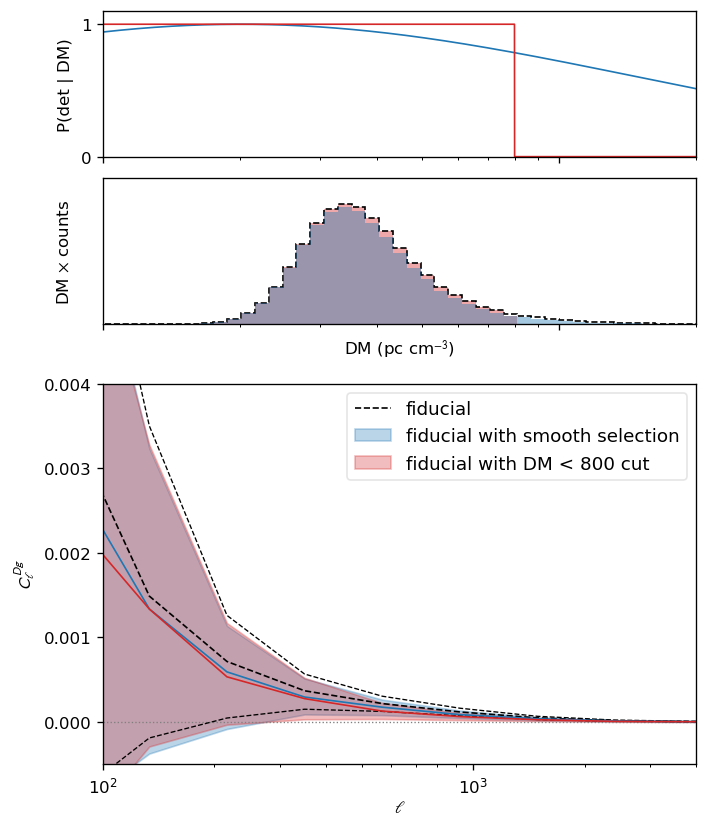

In [41]:
c_smooth = colorcycle[0]
c_step = colorcycle[3]

fig = plt.figure(figsize=(6,7))
gs = gridspec.GridSpec(3, 1, height_ratios=[1, 1, 3])
sub_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[0:2], hspace=0.15)

ax_s = plt.subplot(sub_gs[0])  # upper plot that shows DM sfunc
ax_hist = plt.subplot(sub_gs[1], sharex=ax_s)  # second subplot shows histogram of FRBs
ax = plt.subplot(gs[2])  # Third subplot (independent x-axis)

DMs_ = np.logspace(1, 4, 10000)
ax_s.plot(DMs_, smooth_sfunc(DMs_), color=c_smooth, lw=1, label='smooth selection')

bins = np.logspace(1, 4, 100)
bin_midpoints = (bins[:-1] + bins[1:]) / 2
ax_hist.stairs(H*bin_midpoints, bins, color=fid_c, ls='--')
ax_hist.stairs(H_smooth*bin_midpoints, bins, color=c_smooth, fill=True, alpha=0.4)

ax_s.set_ylabel('P(det | DM)')

ax_s.set_ylim(0,1)
ax_s.set_xlim(100, 2e3)
ax_s.set_xscale('log')
ax_s.set_ylim(top=1.1)
ax_s.set_yticks([0, 1])

# ax_hist.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax_hist.set_ylabel('DM ' + r'$\times$' + ' counts', labelpad=19)
ax_hist.set_xlabel('DM (pc ' + r'cm$^{-3}$)', labelpad=1)
ax_hist.set_ylim(0, 1.8e7)
ax_hist.set_yticks([])
ax_s.set_xticklabels([])

# plot cross correlation
ax.axhline(0, color='gray', ls='dotted', lw=0.8)
plot_ref_ClDg(ax, fid_ClDgs, 1, 0.8, label='fiducial')
plot_xcorr_trials(ells, res['DM_sfunc'][a], ax=ax, color=c_smooth, label='fiducial with smooth selection') 

# plot DM cutoffs
cutoff = 800
ax_s.plot(DMs_, 1-np.heaviside(DMs_-cutoff, 0), color=c_step, lw=1)
step_sfunc_DMs = fid_DMs_[fid_DMs_ < cutoff]
Hstep, _ = np.histogram(step_sfunc_DMs, bins=bins)
ax_hist.stairs(Hstep*bin_midpoints, bins, color=c_step, fill=True, alpha=0.4, zorder=0)
plot_xcorr_trials(ells, res['DM_cutoffs'][cutoff], ax=ax, color=c_step, label=f'fiducial with DM < {cutoff} cut', yscale='linear') 

ax.legend(fontsize=11, loc='upper right')
plt.tight_layout()

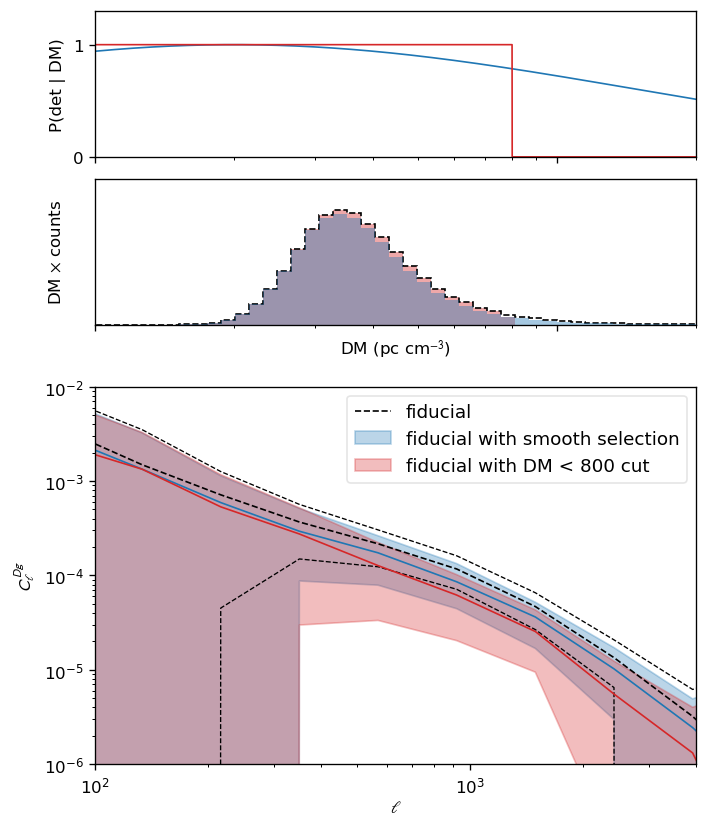

In [42]:
c_smooth = colorcycle[0]
c_step = colorcycle[3]

fig = plt.figure(figsize=(6,7))
gs = gridspec.GridSpec(3, 1, height_ratios=[1, 1, 3])
sub_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[0:2], hspace=0.15)

ax_s = plt.subplot(sub_gs[0])  # upper plot that shows DM sfunc
ax_hist = plt.subplot(sub_gs[1], sharex=ax_s)  # second subplot shows histogram of FRBs
ax = plt.subplot(gs[2])  # Third subplot (independent x-axis)

DMs_ = np.logspace(1, 4, 10000)
ax_s.plot(DMs_, smooth_sfunc(DMs_), color=c_smooth, lw=1, label='smooth selection')

bins = np.logspace(1, 4, 100)
bin_midpoints = (bins[:-1] + bins[1:]) / 2
ax_hist.stairs(H*bin_midpoints, bins, color=fid_c, ls='--')
ax_hist.stairs(H_smooth*bin_midpoints, bins, color=c_smooth, fill=True, alpha=0.4)

ax_s.set_ylabel('P(det | DM)')

ax_s.set_ylim(0,1)
ax_s.set_xlim(100, 2e3)
ax_s.set_xscale('log')
ax_s.set_ylim(top=1.3)
ax_s.set_yticks([0, 1])

# ax_hist.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax_hist.set_ylabel('DM ' + r'$\times$' + ' counts', labelpad=19)
ax_hist.set_xlabel('DM (pc ' + r'cm$^{-3}$)', labelpad=1)
ax_hist.set_ylim(0, 1.9e7)
ax_hist.set_yticks([])
ax_s.set_xticklabels([])

# plot cross correlation
plot_ref_ClDg(ax, fid_ClDgs, 1, 0.8, label='fiducial')
plot_xcorr_trials(ells, res['DM_sfunc'][a], ax=ax, color=c_smooth, label='fiducial with smooth selection') 

# plot DM cutoffs
cutoff = 800
ax_s.plot(DMs_, 1-np.heaviside(DMs_-cutoff, 0), color=c_step, lw=1)
step_sfunc_DMs = fid_DMs_[fid_DMs_ < cutoff]
Hstep, _ = np.histogram(step_sfunc_DMs, bins=bins)
ax_hist.stairs(Hstep*bin_midpoints, bins, color=c_step, fill=True, alpha=0.4, zorder=0)
plot_xcorr_trials(ells, res['DM_cutoffs'][cutoff], ax=ax, color=c_step, label=f'fiducial with DM < {cutoff} cut') 

ax.legend(fontsize=11, loc='upper right')
plt.tight_layout()

# ax_s.set_title('DM-dependent selection effects', pad=10)
# ax_s.text(.98, .93, 'DM-dependent selection function', va='top', ha='right', fontsize=9, transform=ax_s.transAxes)
# ax_hist.text(.98, .93, 'DM distribution under selection effects', va='top', ha='right', fontsize=9, transform=ax_hist.transAxes)
plt.savefig(os.path.join(figpath, 'DM_sfunc.pdf'))

## scattering selection effects

We test the effect of scattering selection effects. For each host galaxy, we calculate the impact parameter $b$ to each galaxy in the foreground. The probability of scattering is modelled as
$$P_{\rm{scatter}}(\tau)= 1 - 2^{-\left( \frac{\tau}{1\,\mathrm{ms}} \right)^2}  $$
where the scattering timescale $\tau$ is modelled as
$$ \tau = 0.3\,\rm{ms}\,\frac{G}{(1+z_\ell)^3(\frac{\nu}{\rm{1\, Ghz}})^4} 2^{-\left( \frac{b_{\perp}}{4\,\mathrm{kpc}}\right)^2} $$
and we sum over the scattering timescales from all intervening galaxies with impact parameter $b_\perp$ and geometric leverage factor $G$.

In [8]:
scatterbins = np.linspace(0,1,101)
Hscatter, _ = np.histogram(scatterPs_slice, bins=scatterbins)

print(f'slice mean scatter P: {np.mean(scatterPs_slice)}')
print(f'slice median scatter P: {np.median(scatterPs_slice)}')

print(f'full mean scatter P: {np.mean(scatterPs_full)}')
print(f'full median scatter P: {np.median(scatterPs_full)}')

slice mean scatter P: 0.13708720428242582
slice median scatter P: 0.0
full mean scatter P: 0.11186910309706707
full median scatter P: 0.0


Text(0.5, 1.0, 'distribution of host $P_\\text{scatter}$, $0.3 < z_\\text{host} \\leq 0.4$')

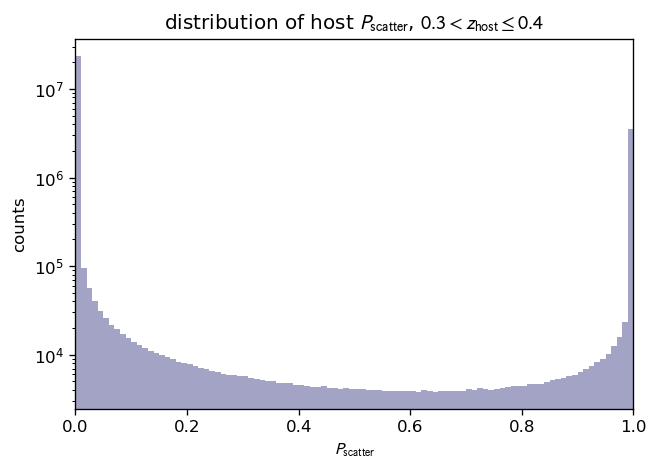

In [11]:
c = 'midnightblue'
plt.stairs(Hscatter, scatterbins, fill=True, color=c, alpha=0.4, label=r'$0.3 < z_\text{host} \leq 0.4$')
plt.yscale('log')

plt.xlabel(r'$P_\text{scatter}$')
plt.ylabel('counts')
plt.xlim(0,1)
plt.title(r'distribution of host $P_\text{scatter}$, $0.3 < z_\text{host} \leq 0.4$')

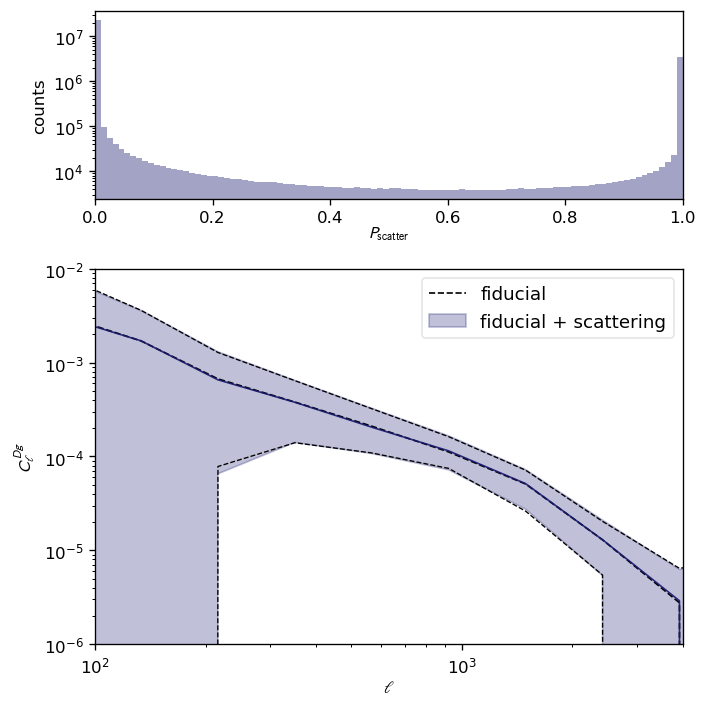

In [18]:
# combine with power spectra

c = 'midnightblue'

gs = gridspec.GridSpec(2, 1, height_ratios=[1, 2])
fig = plt.figure(figsize=(6,6))

ax_hist = fig.add_subplot(gs[0])
ax = fig.add_subplot(gs[1])

# DM host histogram
ax_hist.stairs(Hscatter, scatterbins, fill=True, color=c, alpha=0.4, label=r'$0.3 < z_\text{host} \leq 0.4$')
ax_hist.set_yscale('log')

ax_hist.set_xlabel(r'$P_\text{scatter}$', labelpad=0)
ax_hist.set_ylabel('counts')
ax_hist.set_xlim(0,1)

# ax_hist.text(.98, 0.93, r'$P_\text{scatter}$ distribution of host galaxies, $0.3 < z_\text{host} \leq 0.4$', va='top', ha='right', fontsize=10, transform=ax_hist.transAxes)
# ax_hist.set_title(r'distribution of host $P_\text{scatter}$, $0.3 < z_\text{host} \leq 0.4$')

# cross-correlation
subplot_from_list((res['scatter_ClDgs'],), ax=ax, colors=(c,), ref_ClDg=fid_ClDgs, ref_label='fiducial', labels=('fiducial + scattering',), yscale='log')
ax.legend()

plt.tight_layout()

plt.savefig(os.path.join(figpath, 'scattering.pdf'))

(90, 4000)

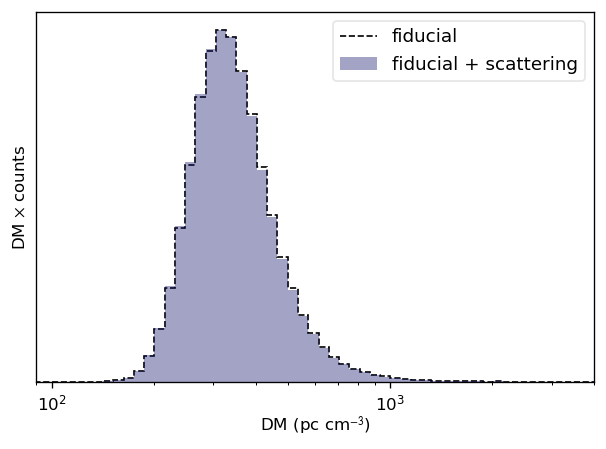

In [10]:
# compare DM distribution

c = 'midnightblue'

bins = np.logspace(1, 4, 100)
bin_midpoints = (bins[:-1] + bins[1:]) / 2

fig, ax = plt.subplots()

H_fid, _ = np.histogram(fid_DMs_, bins=bins, density=True)
ax.stairs(H_fid*bin_midpoints, bins, color=fid_c, ls='--', label='fiducial')

DM_scatter = np.stack(res['trial_DM_fields']['DM_scatter'], axis=0)
mult_scatter = np.stack(res['trial_DM_fields']['mult_scatter'], axis=0)
H_scatter, _ = np.histogram(DM_scatter[mult_scatter > 0].flatten(), bins=bins, density=True)
ax.stairs(H_scatter*bin_midpoints, bins, color=c, fill=True, alpha=0.4, label='fiducial + scattering')

ax.legend()

ax.set_ylabel('DM ' + r'$\times$' + ' counts', labelpad=5)
ax.set_xlabel('DM (pc ' + r'cm$^{-3}$)', labelpad=1)
ax.set_yticks([])
ax.set_xscale('log')
ax.set_xlim((90, 4000))

# plt.savefig(os.path.join(figpath, 'DM_scattering.pdf'))

## galaxy luminosity selection effects

In [49]:
m_g_cutoffs = list(res['m_g_cutoffs'].keys())
m_g_cutoffs

[25.4, 20.7]

In [50]:
# get galaxy magnitude data
m_gs = []
Clgg_dict = {}
for regname in regions.keys():
    sim = exp_simulation(500 * np.array([50, 70, 23]), regname)
    g_df = sim.read_shell_galaxies(zrange=g_zrange)
    
    m_gs.append(np.array(g_df['m_g']))

    # compare auto spectrum 
    for m_g_cutoff in [None] + m_g_cutoffs:
        Ngal_grid = sim.Ngal_grid(df=g_df, m_g_cutoff=m_g_cutoff)
        delta_g = (Ngal_grid / np.mean(Ngal_grid)) - 1
        ells_gg, Clgg = cross_power_estimator(delta_g, delta_g, nbins=20)
        if m_g_cutoff not in Clgg_dict.keys():
            Clgg_dict[m_g_cutoff] = []
        Clgg_dict[m_g_cutoff].append(np.array(Clgg))

m_gs = np.concatenate(m_gs)

In [71]:
for cutoff in sorted(m_g_cutoffs):
    print(f'% Complete at {cutoff}: {np.sum(m_gs < cutoff) / len(m_gs) * 100 : .2f}')

% Complete at 20.7:  5.00
% Complete at 25.4:  28.88


(5e-05, 0.005)

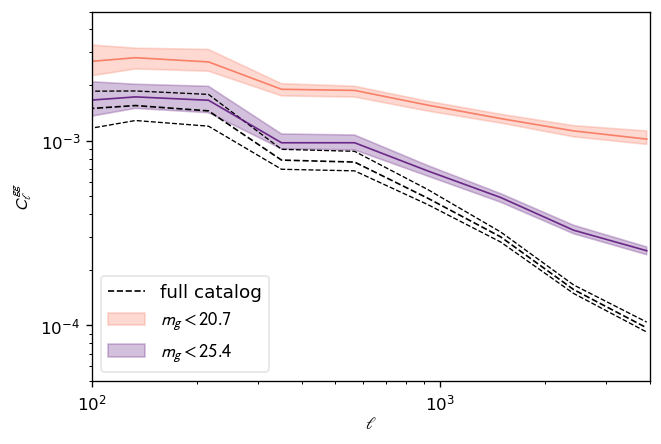

In [193]:
# compare Clggs

fig, ax_Cl = plt.subplots()
colors=[magma[1], magma[4]]

plot_ref_ClDg(ax_Cl, Clgg_dict[None], 1, 0.8, ells=ells_gg, label='full catalog', color=fid_c)
subplot_from_dict(Clgg_dict, sorted(m_g_cutoffs), ells=ells_gg, labels=lambda x: f'$m_g < {x}$', colors=colors, ax=ax_Cl,
                    ref_ClDg=None, ylabel=r'$C_\ell^{gg}$')
ax_Cl.set_ylim(5e-5, 5e-3)

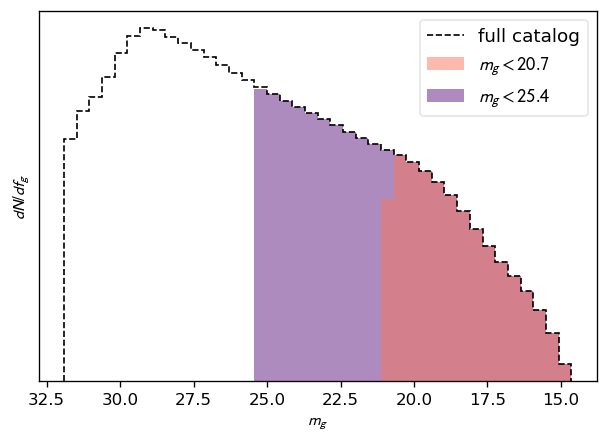

In [74]:
# m_g histogram
# colors=[flare[3], flare[1]]
colors=[magma[1], magma[4]]

fig, ax = plt.subplots()
ax.invert_xaxis()

m_g_bins = np.linspace(-np.amax(m_gs), -np.amin(m_gs), 41) # magnitude should increase to the left
m_g_mids = -(m_g_bins[:-1] + m_g_bins[1:]) / 2
H, _ = np.histogram(-m_gs, bins=m_g_bins)
ax.stairs(H / (0.4*10**(-0.4*m_g_mids)), -m_g_bins, ls='--', label='full catalog', color=fid_c)
for i, cutoff in enumerate(sorted(m_g_cutoffs)):
    mask = m_gs < cutoff
    Hmask, _ = np.histogram(-m_gs[mask], bins=m_g_bins)
    ax.stairs(Hmask / (0.4*10**(-0.4*m_g_mids)), -m_g_bins, fill=True, alpha=0.5,  label=f'$m_g < {cutoff}$', color=colors[i], zorder=-i)

ax.set_ylabel('$dN/df_g$')
ax.set_xlabel(r'$m_g$')
ax.set_yscale('log')
# ax.set_ylim(10, 3e7)
# ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.set_yticks([])

ax.legend()


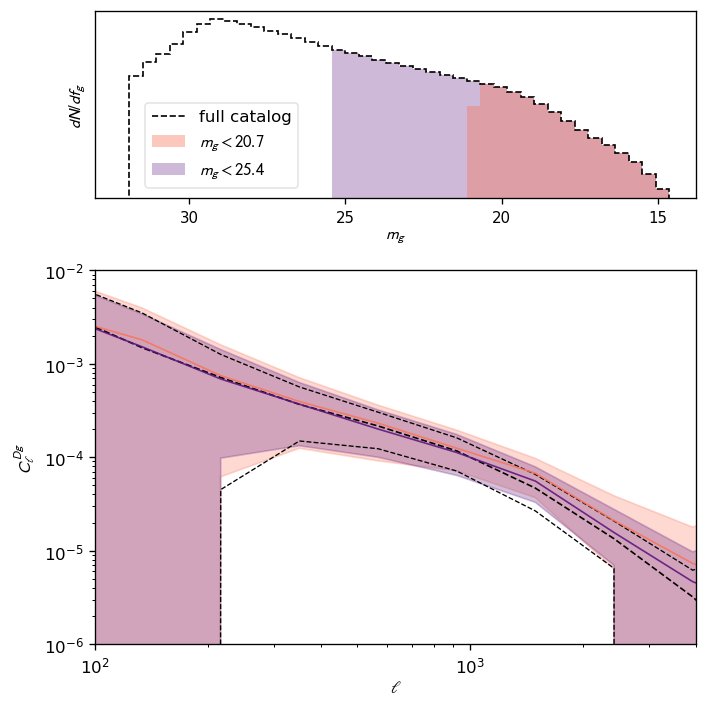

In [89]:
# combine with power spectra

colors=[magma[1], magma[4]]

gs = gridspec.GridSpec(2, 1, height_ratios=[1, 2])
fig = plt.figure(figsize=(6,6))

ax = fig.add_subplot(gs[0])
ax.invert_xaxis()
ax_Cl = fig.add_subplot(gs[1])

# galaxy selection histogram
m_g_bins = np.linspace(-np.amax(m_gs), -np.amin(m_gs), 41) # magnitude should increase to the left
m_g_mids = -(m_g_bins[:-1] + m_g_bins[1:]) / 2
H, _ = np.histogram(-m_gs, bins=m_g_bins)
ax.stairs(H / (0.4*10**(-0.4*m_g_mids)), -m_g_bins, ls='--', label='full catalog', color=fid_c)
for i, cutoff in enumerate(sorted(m_g_cutoffs)):
    mask = m_gs < cutoff
    Hmask, _ = np.histogram(-m_gs[mask], bins=m_g_bins)
    ax.stairs(Hmask / (0.4*10**(-0.4*m_g_mids)), -m_g_bins, fill=True, alpha=0.4-0.1*i,  label=f'$m_g < {cutoff}$', color=colors[i], zorder=-i)

ax.set_ylabel('$dN / df_g$')
ax.set_xlabel(r'$m_g$', labelpad=2)
ax.set_yscale('log')
ax.set_yticks([])
ax.tick_params(axis='x', labelsize=9)
ax.set_xticks([30, 25, 20, 15])
ax.set_xlim(left=33)
# ax.set_title(r'galaxy magnitude cut, $0.2 < z_g \leq 0.3$')
ax.legend(fontsize=10, loc='lower left', bbox_to_anchor=(0.07, .01))

# bottom plot: power spectrum
subplot_from_dict(res['m_g_cutoffs'], ax=ax_Cl, whichkeys=sorted(m_g_cutoffs), labels=lambda x: f'$m_g < {x}$', colors=colors,
                  ref_ClDg=fid_ClDgs, ref_label='full catalog', yscale='log', legend=False)
plt.tight_layout()

plt.savefig(os.path.join(figpath, 'galaxy_mag.pdf'))

## optical follow-up selection effects

Impose an apparent magnitude cutoff to the host galaxies, modelling the fact that only FRBs with bright host galaxies will be able to be localized.

In [13]:
# get galaxy magnitude data, this time for the background 'host' slice 
m_gs = []
for regname in regions.keys():
    sim = exp_simulation(500 * np.array([50, 70, 23]), regname)
    g_df = sim.read_shell_galaxies(zrange=frb_zrange)
    
    m_gs.append(np.array(g_df['m_g']))

m_gs = np.concatenate(m_gs)

% Complete at 20.7:  2.61
% Complete at 25.4:  23.25


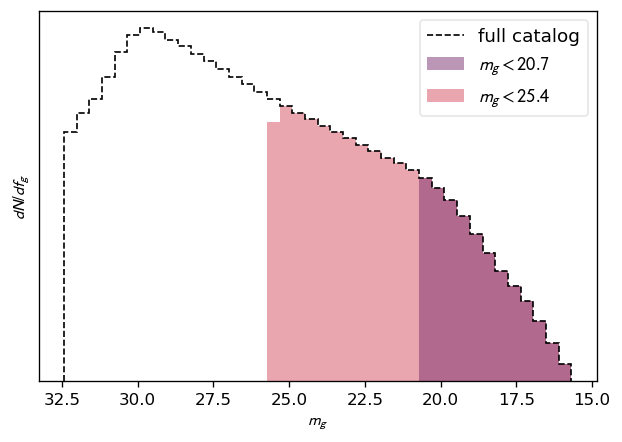

In [15]:
m_host_cutoffs = [25.4, 20.7]

for cutoff in sorted(m_host_cutoffs):
    print(f'% Complete at {cutoff}: {np.sum(m_gs < cutoff) / len(m_gs) * 100 : .2f}')

# m_g histogram
colors=[flare[3], flare[1]]

fig, ax = plt.subplots()
ax.invert_xaxis()

m_g_bins = np.linspace(-np.amax(m_gs), -np.amin(m_gs), 41) # magnitude should increase to the left
m_g_mids = -(m_g_bins[:-1] + m_g_bins[1:]) / 2
H, _ = np.histogram(-m_gs, bins=m_g_bins)
ax.stairs(H / (0.4*10**(-0.4*m_g_mids)), -m_g_bins, ls='--', label='full catalog', color=fid_c)
for i, cutoff in enumerate(sorted(m_host_cutoffs)):
    mask = m_gs < cutoff
    Hmask, _ = np.histogram(-m_gs[mask], bins=m_g_bins)
    ax.stairs(Hmask / (0.4*10**(-0.4*m_g_mids)), -m_g_bins, fill=True, alpha=0.5,  label=f'$m_g < {cutoff}$', color=colors[i], zorder=-i)

ax.set_ylabel('$dN/df_g$')
ax.set_xlabel(r'$m_g$')
ax.set_yscale('log')
# ax.set_ylim(10, 3e7)
# ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.set_yticks([])

ax.legend()

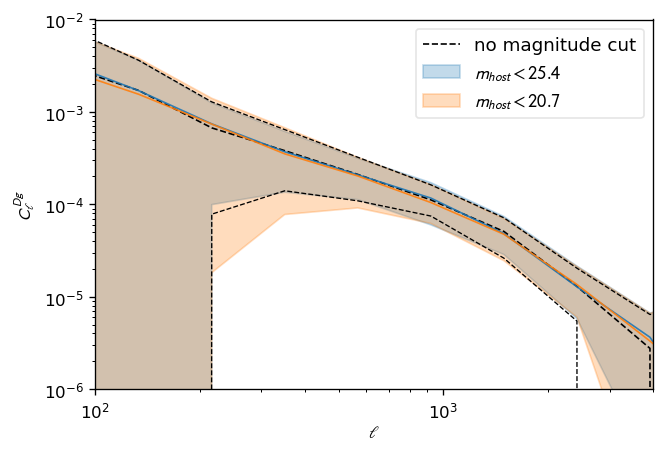

In [12]:
subplot_from_dict(res['host_m_g_cutoffs'], whichkeys=m_host_cutoffs, labels=lambda x: r'$m_{host}' + f'< {x}$',
                  ref_ClDg=fid_ClDgs, ref_label='no magnitude cut')

## cross-correlation is robust to combined effects

In [8]:
subdict = combined_res['slice_exp']

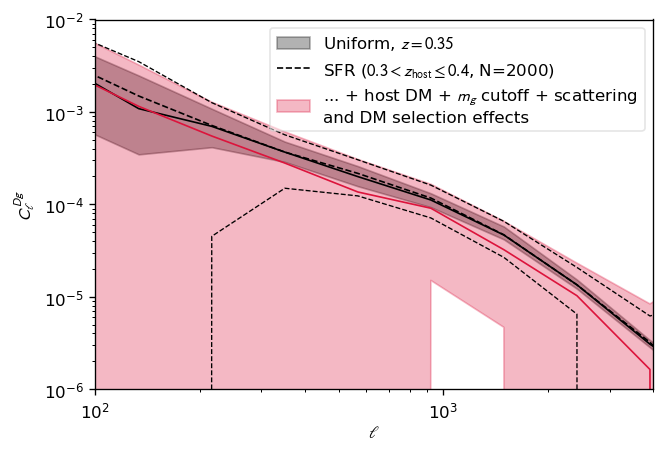

In [202]:
fig, ax = plt.subplots() 

plot_xcorr_trials(ells, combined_res['midslice']['ClDgs'], ax=ax, color='k', label=f'Uniform, $z={frb_mean_z:.2f}$')
plot_ref_ClDg(ax, fid_ClDgs, 1, 0.8, label=r'SFR ($0.3 < z_\text{host} \leq 0.4$, N=2000)')
# plot_xcorr_trials(ells, subdict['ClDgs'][n_frbs], ax=ax, color='seagreen', label='... + host DM')
plot_xcorr_trials(ells, subdict['ClDgs_exp'][n_frbs], ax=ax, color='crimson', label='... + host DM + $m_g$ cutoff + scattering\nand DM selection effects')
legend = ax.legend(fontsize=10, loc='upper right')

plt.savefig(os.path.join(figpath, 'combined_log.pdf'))

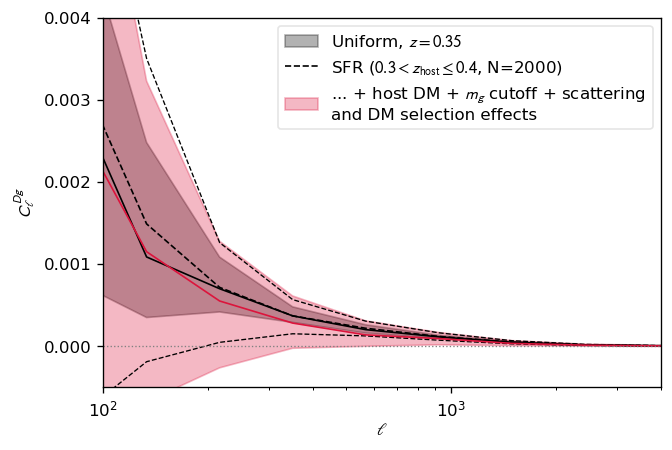

In [9]:
fig, ax = plt.subplots() 

plot_xcorr_trials(ells, combined_res['midslice']['ClDgs'], ax=ax, color='k', label=f'Uniform, $z={frb_mean_z:.2f}$')
plot_ref_ClDg(ax, fid_ClDgs, 1, 0.8, label=r'SFR ($0.3 < z_\text{host} \leq 0.4$, N=2000)')
# plot_xcorr_trials(ells, subdict['ClDgs'][n_frbs], ax=ax, color='seagreen', label='... + host DM')
plot_xcorr_trials(ells, subdict['ClDgs_exp'][n_frbs], ax=ax, color='crimson', label='... + host DM + $m_g$ cutoff + scattering\nand DM selection effects', yscale='linear')
legend = ax.legend(fontsize=10, loc='upper right')

ax.axhline(0, color='gray', ls='dotted', lw=0.8)

plt.savefig(os.path.join(figpath, 'combined_linear.pdf'))

## epilogue: FRB placement model and number of FRBs

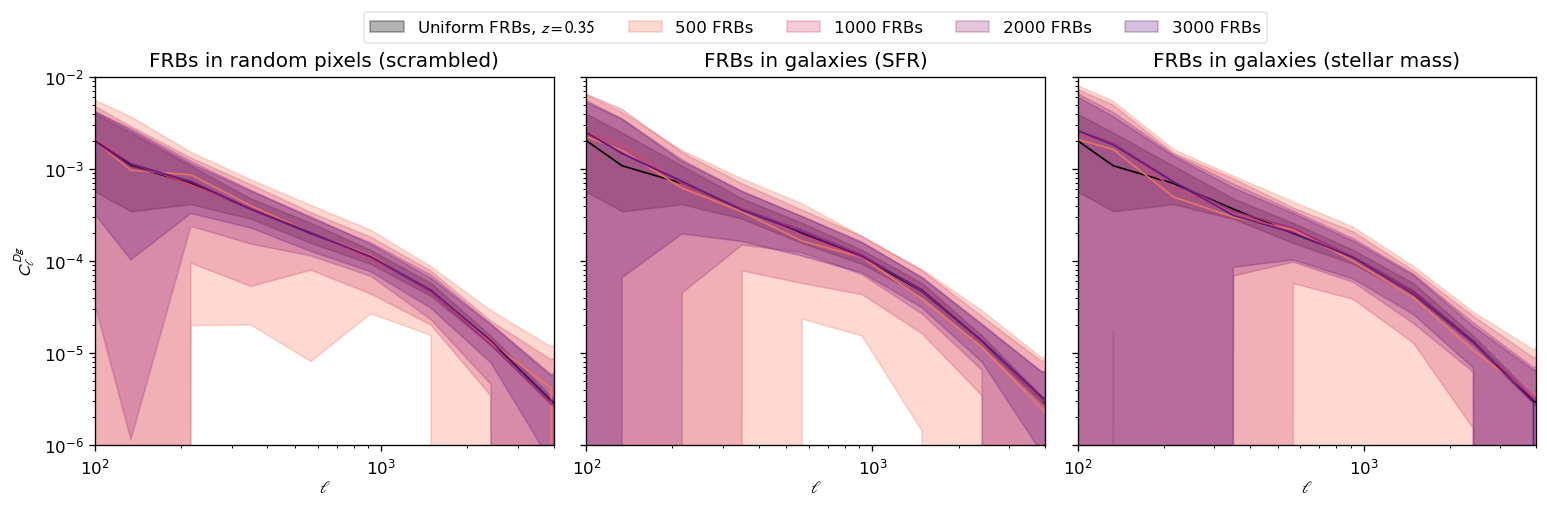

In [219]:
fig, axes = generate_plots((res['n_frbs_randpixels'], res['n_frbs_sfrweight'],res['n_frbs_massweight']), ref_lws=(1,.8), ref_ClDg=midslice_ClDgs,
                   titles=(f'FRBs in random pixels (scrambled)', 'FRBs in galaxies (SFR)', 'FRBs in galaxies (stellar mass)'),
                   whichkeys=(500, 1000, 2000, 3000), labels=lambda x: f'{x} FRBs', colors=magma[1:], legend=False,
                   plotinterval=True, yscale='log')
axes[1].legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=5)
plt.savefig(os.path.join(figpath, 'frb_model.pdf'))

Where the FRBs are matters - projecting the FRBs into galaxies (i.e. putting them into the pixels where the galaxies are) increases the variance compared to putting them into random pixels!

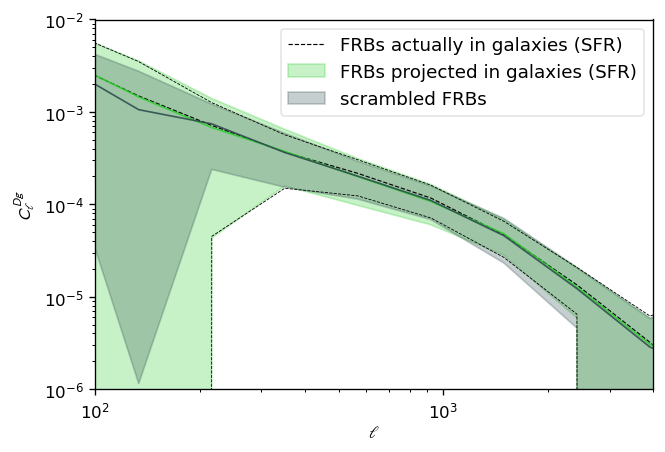

In [229]:
fig, ax = plt.subplots()
plot_ref_ClDg(ax, fid_ClDgs, label=f'FRBs actually in galaxies (SFR)')
subplot_from_list((res['proj_sfrweight_ClDgs'], res['n_frbs_randpixels'][2000]), colors=('limegreen', 'darkslategray'), ax=ax,
                  labels=('FRBs projected in galaxies (SFR)', 'scrambled FRBs'))
ax.legend()

plt.savefig(os.path.join(figpath, 'proj_FRBs.pdf'))

## epilogue: FRBs overlapping with foreground galaxies

Investigation data from `runinvestigation.py`, to look at why the cross-correlation was increasing when the FRBs were overlapping with the foreground galaxies. I didn't save 3D information from my last run, so I just re-ran a subset of the experiments.

In [25]:
new_res_path = '/ceph/submit/data/group/submit-illustris/april/data/C_ells/trial_investigation_DMs.pkl'
with open(new_res_path, 'rb') as f:
    new_res = pickle.load(f)

def get_mean_DM_x(DM, x1z, mask=True):
    if type(DM) == list:
        DM = np.stack(DM, axis=0)
    if type(x1z) == list:
        x1z = np.stack(x1z, axis=0)
    k = np.sum(DM[mask]) / np.sum(x1z[mask])
    return k * x1z

def Cls_from_fields(DMs, delta_gs, ntrials=1, mults=None, mean_DMs=None, nbins=nbins):
    Cls = []
    if mean_DMs is None:
        mean_DMs = np.mean(DMs, axis=(1,2))
    for i, DM in enumerate(DMs):
        ells, Cl = cross_power_estimator(DM - mean_DMs[i], delta_gs[i//ntrials], nbins=nbins)
        if mults is None:
            Cls.append(Cl)
        else:
            Cls.append(Cl / np.mean(mults[i]))
    return ells, np.vstack(Cls)

In [29]:
delta_gs = new_res['g_zranges'][g_zrange]
ntrials = 5 # per region, but we only want one trial per region

Cl, Cl_mcq, Cl_midslice = {}, {}, {}
for zrange in new_res['frb_zranges'].keys():
    subdict = new_res['frb_zranges'][zrange]
    DM_midslice, DM, x1z, mult = np.stack(subdict['DM_midslice'], axis=0), \
                    np.stack(subdict['DM_trial'], axis=0), \
                    np.stack(subdict['x1z_trial'], axis=0), \
                    np.stack(subdict['mult_trial'], axis=0)
    ells, Cl_mcq_ = Cls_from_fields(DM, delta_gs, ntrials=ntrials, mults=mult, 
                                 mean_DMs=get_mean_DM_x(DM, x1z, mult > 0))
    ells, Cl_ = Cls_from_fields(DM, delta_gs, ntrials=ntrials, mults=mult)
    ells, Cl_midslice_ = Cls_from_fields(DM_midslice, delta_gs)
    Cl[zrange], Cl_mcq[zrange], Cl_midslice[zrange] = Cl_, Cl_mcq_, Cl_midslice_

In [12]:
from scipy.interpolate import interp1d

z = np.linspace(0.01, 0.5, 100000)
x1z = sim.comoving_distance(z) * (1 + z)
z_from_x1z = interp1d(x1z, z)

In [13]:
# also try just subtracting the mean DM in chunks

def get_mean_DM_chunk(DM, x1z, mask, zranges = [(0, g_zrange[0]), (g_zrange[0], g_zrange[1]), (g_zrange[1], 1)]):
    mean_DM = np.zeros_like(DM)
    z =  np.zeros_like(x1z)
    z[mask] = z_from_x1z(x1z[mask])
    for zrange in zranges:
        mask_ = mask & (z > zrange[0]) & (z <= zrange[1])
        if np.any(mask_):
            mean_DM[mask_] = np.mean(DM[mask_])
    return mean_DM


Cl_zchunk, Cl_zchunk_corrected = {}, {}
for zrange in new_res['frb_zranges'].keys():
    subdict = new_res['frb_zranges'][zrange]
    DM, x1z, mult = np.stack(subdict['DM_trial'], axis=0), \
                    np.stack(subdict['x1z_trial'], axis=0), \
                    np.stack(subdict['mult_trial'], axis=0)
    Cl_zchunk[zrange] = Cls_from_fields(DM, delta_gs, ntrials=ntrials, mults=mult, 
                                        mean_DMs=get_mean_DM_chunk(DM, x1z, mult > 0))[1]
    
    mask = np.stack( subdict['mult_trial'], axis=0 ) > 0
    z = np.zeros_like(x1z)
    z[mask] = z_from_x1z(x1z[mask])
    f0 = np.mean((z > g_zrange[0]) & (z <= g_zrange[1]), axis=(1,2))
    f1 = np.mean((z > g_zrange[1]), axis=(1,2))
    f = np.mean(mask, axis=(1,2))
    Cl_zchunk_corrected[zrange] = Cl_zchunk[zrange] / np.atleast_2d((0.5*f0 + f1)/f).T

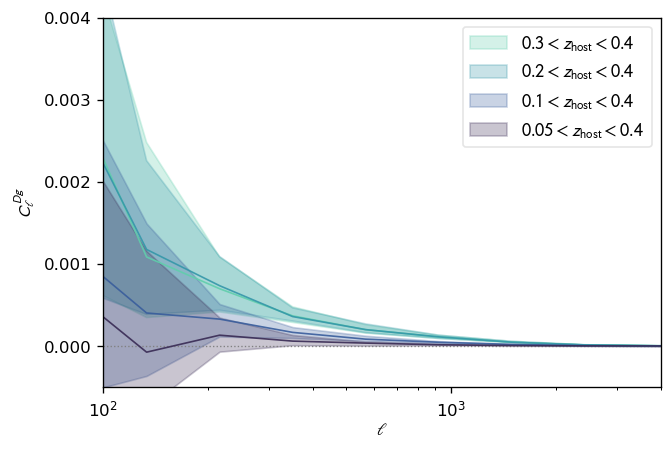

In [30]:
subplot_from_dict(Cl_midslice, whichkeys=[(0.3, 0.4), (0.2, 0.4), (0.1, 0.4), (0.05, 0.4)],
                labels=lambda x: f'${x[0]} < ' + r'z_\text{host}' + f' < {x[1]}$', 
                colors=mako, legend=True, yscale='linear')

This shows FRBs in a single layer at various redshifts. As expected, as the FRBs are further and further into the foreground of the galaxies, the cross-correlation decreases.

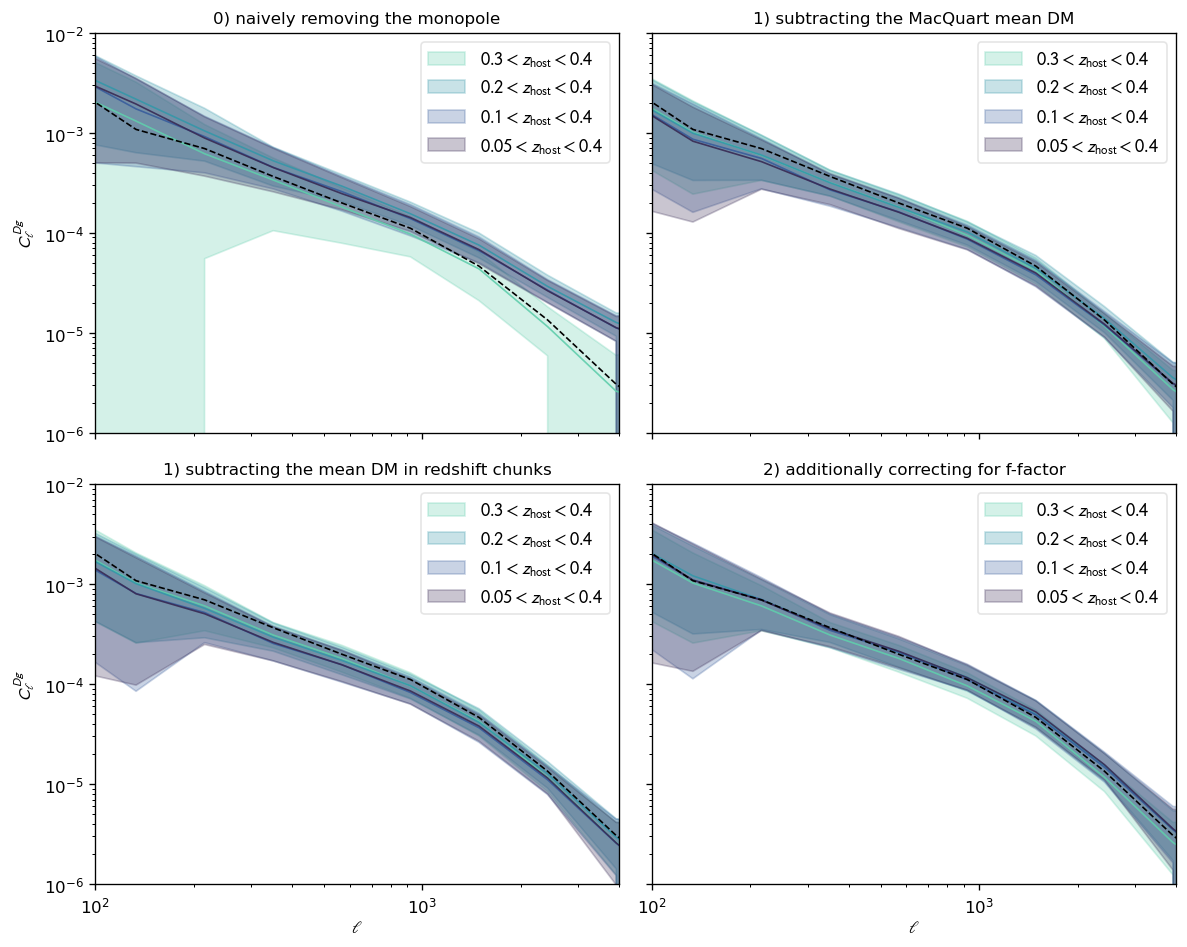

In [38]:
fig, axes_ = plt.subplots(2, 2, figsize=(10,8), sharex=True, sharey=True)
axes = axes_.flatten()

ref_Cls = np.median(Cl_midslice[(0.3, 0.4)], axis=0)

titles = ['0) naively removing the monopole', '1) subtracting the MacQuart mean DM', '1) subtracting the mean DM in redshift chunks', '2) additionally correcting for f-factor']
for i, Cldict in enumerate([Cl, Cl_mcq, Cl_zchunk, Cl_zchunk_corrected]):
    ax = axes[i]
    subplot_from_dict(Cldict, whichkeys=[(0.3, 0.4), (0.2, 0.4), (0.1, 0.4), (0.05, 0.4)],
                      labels=lambda x: f'${x[0]} < ' + r'z_\text{host}' + f' < {x[1]}$', 
                      colors=mako, ax=ax, legend=True)
    if i % 2:
        ax.set_ylabel('')
    if i < 2:
        ax.set_xlabel('')
    ax.plot(ells, ref_Cls, color='k', ls='--', lw=1)
    ax.set_title(titles[i], fontsize=10)
plt.tight_layout()

plt.savefig(os.path.join(figpath, 'overlap_correction.pdf'))

See my notes (`scratch.pdf`) for why this happens, and what e.g. the f-factor is

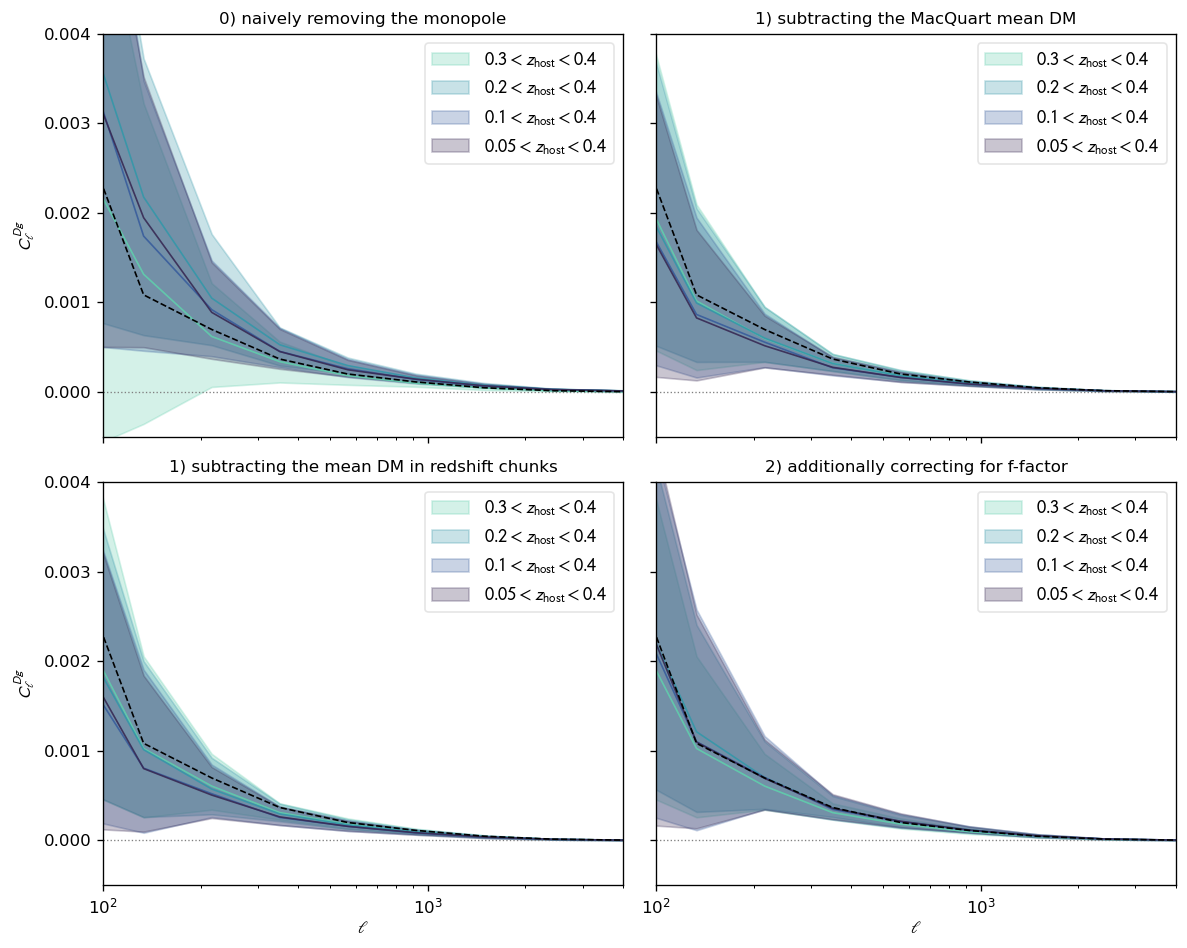

In [39]:
fig, axes_ = plt.subplots(2, 2, figsize=(10,8), sharex=True, sharey=True)
axes = axes_.flatten()

ref_Cls = np.median(Cl_midslice[(0.3, 0.4)], axis=0)

titles = ['0) naively removing the monopole', '1) subtracting the MacQuart mean DM', '1) subtracting the mean DM in redshift chunks', '2) additionally correcting for f-factor']
for i, Cldict in enumerate([Cl, Cl_mcq, Cl_zchunk, Cl_zchunk_corrected]):
    ax = axes[i]
    subplot_from_dict(Cldict, whichkeys=[(0.3, 0.4), (0.2, 0.4), (0.1, 0.4), (0.05, 0.4)],
                      labels=lambda x: f'${x[0]} < ' + r'z_\text{host}' + f' < {x[1]}$', 
                      colors=mako, ax=ax, legend=True, yscale='linear')
    if i % 2:
        ax.set_ylabel('')
    if i < 2:
        ax.set_xlabel('')
    ax.plot(ells, ref_Cls, color='k', ls='--', lw=1)
    ax.set_title(titles[i], fontsize=10)
plt.tight_layout()

plt.savefig(os.path.join(figpath, 'overlap_correction_linear.pdf'))